# Data Science & AI/ML — Practical Exam (Set D: Campaign Response)
## Section A — Technical Work (Tasks 1 to 5)

**Student name:** Isamaliya Ayush |  **Student ID:** 11225  |  **Set:** D



| Part | Content |
|---|---|
| Setup | Imports, data generation, audit and split (Task 2 – F1, done first because every task needs the split) |
| Task 1 | Maths & Advanced Statistics (M1, M2, M3) |
| Task 2 | Preprocessing & Feature Engineering (F2, F3) |
| Task 3 | Supervised Learning (S1, S2, S3) |
| Task 4 | Unsupervised Learning (U1, U2) |
| Task 5 | Deep Learning: ANN (D1, D2, D3) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



## Dataset

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(404)
n = 300
cols = ['visits', 'recency', 'engagement', 'spend']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, -0.9, 1.1, 0.4])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["response"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_d.csv", index=False)


## Audit the raw data

In [3]:
raw = pd.read_csv("data/raw/set_d.csv")
raw.head()

,record_id,visits,recency,engagement,spend,group,response
0,1,53.96,43.84,54.57,58.93,G2,1
1,2,NaN,49.75,52.97,63.64,G2,1
2,3,35.39,66.52,44.98,47.33,G2,0
3,4,45.01,42.80,47.62,54.48,G1,1
4,5,53.84,53.72,48.33,58.30,G2,1


In [4]:
print("Raw shape:", raw.shape)
print("Exact duplicate rows:", raw.duplicated().sum())

Raw shape: (305, 7)
Exact duplicate rows: 5


In [5]:
raw.isna().sum()

record_id      0
visits        16
recency       15
engagement     0
spend          0
group          0
response       0
dtype: int64

In [6]:
#  raw

In [7]:
raw['response'].value_counts()

response
1    177
0    128
Name: count, dtype: int64

### Interpretation: 
> 305 rows and 7 columns,
> 5 --> duplicate rows 

> Missing values : visits (16) and recency (15). 

> The target is not perfectly balanced: about 58 % of records are responders (177 of 305). 

## Remove duplicates and verify 300 unique records

In [8]:
df = raw.drop_duplicates().reset_index(drop=True)
print("Clean shape:", df.shape)
print("Unique record_id values:", df["record_id"].nunique())

Clean shape: (300, 7)
Unique record_id values: 300


In [9]:
df["response"].value_counts()

response
1    173
0    127
Name: count, dtype: int64

## Split: 80 % train-pool / 20 % test (stratified, random_state=42)

In [10]:
from sklearn.model_selection import train_test_split
train_pool, test = train_test_split(df, test_size=0.20, stratify=df["response"], random_state=42)

In [11]:
print(train_pool.shape)
print(test.shape)

(240, 7)
(60, 7)


In [12]:
fit, val = train_test_split(train_pool, test_size=0.20, stratify=train_pool["response"], random_state=42)

In [13]:
print(fit.shape)
print(val.shape)
print(test.shape)

(192, 7)
(48, 7)
(60, 7)


In [14]:
fit_ids = pd.DataFrame({"record_id": fit["record_id"], "split": "fit"})
val_ids = pd.DataFrame({"record_id": val["record_id"], "split": "validation"})
test_ids = pd.DataFrame({"record_id": test["record_id"], "split": "test"})

In [15]:
splits = pd.concat([fit_ids, val_ids, test_ids]).sort_values("record_id")
splits.to_csv("outputs/splits.csv", index=False)

# Task 1 — Maths & Advanced Statistics

In [16]:
eng = fit["engagement"].dropna()    
n_eng = len(eng)
print("Observed n:", n_eng)

Observed n: 192


In [17]:
eng_mean = eng.mean()
eng_median = eng.median()
eng_std = eng.std(ddof=1)           
print("Mean  :", round(eng_mean, 4))
print("Median:", round(eng_median, 4))
print("Std   :", round(eng_std, 4))

Mean  : 51.0018
Median: 51.405
Std   : 10.289


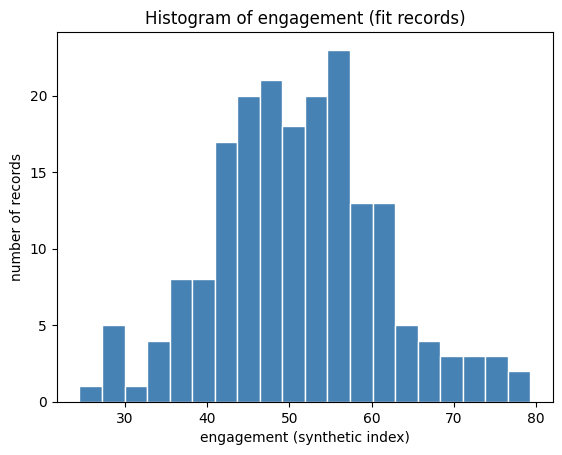

In [18]:
plt.hist(eng, bins=20, color="steelblue", edgecolor="white")
plt.title("Histogram of engagement (fit records)")
plt.xlabel("engagement (synthetic index)")
plt.ylabel("number of records")
plt.savefig("outputs/figures/engagement_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

> **Interpretation :** The histogram is bell-shaped, with a slightly longer tail on the right but no extreme outliers.

### M2 — Welch t-test (G1 vs G2) and 95 % confidence interval

- **H0:** mean engagement of G1 = mean engagement of G2
- **H1:** mean engagement of G1 != mean engagement of G2  (two-sided, alpha = 0.05)

In [19]:
g1 = fit.loc[fit["group"] == "G1", "engagement"].dropna()
g2 = fit.loc[fit["group"] == "G2", "engagement"].dropna()
print("G1 count:", len(g1), "| G1 mean:", round(g1.mean(), 3))
print("G2 count:", len(g2), "| G2 mean:", round(g2.mean(), 3))

G1 count: 84 | G1 mean: 51.615
G2 count: 108 | G2 mean: 50.525


In [20]:
from scipy import stats

welch = stats.ttest_ind(g1, g2, equal_var=False)
print("t statistic:", round(welch.statistic, 4))
print("p-value    :", round(welch.pvalue, 4))

t statistic: 0.723
p-value    : 0.4707


In [21]:
ci_low, ci_high = stats.t.interval(0.95, 
                                   df=n_eng - 1, 
                                   loc=eng_mean, 
                                   scale=stats.sem(eng))

print("95% CI :", round(ci_low, 3), "to", round(ci_high, 3))

95% CI : 49.537 to 52.466


> **Interpretation** : The Welch test gives t = 0.72 and p = 0.47.
> Since p > 0.05 we fail to reject H0.

## M3 — Linear algebra: covariance matrix and eigenvalues

In [22]:
X = fit[["engagement", "visits"]].dropna().values  
n_rows = X.shape[0]
print("Rows used:", n_rows)

Rows used: 181


In [23]:
X_centered = X - X.mean(axis=0)

In [24]:
cov = X_centered.T @ X_centered / (n_rows - 1)
cov

array([[103.65708913,   4.11811311],
       [  4.11811311, 103.06117496]])

In [25]:
eigenvalues, eigenvectors = np.linalg.eigh(cov)
print("Eigenvalues:", eigenvalues.round(3))

Eigenvalues: [ 99.23  107.488]


In [26]:
largest_share = eigenvalues[-1] / eigenvalues.sum()
print("Largest eigenvalue / sum of eigenvalues:", round(largest_share, 4))

Largest eigenvalue / sum of eigenvalues: 0.52


>**Interpretation:** The largest eigenvalue (107.5) is 52 % of the total variance (the sum of eigenvalues).

# Task 2 — Preprocessing & Feature Engineering


In [27]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [28]:
num_cols = ["visits", "recency", "engagement", "spend"]
imputer = SimpleImputer(strategy="median")
imputer.fit(fit[num_cols])

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [29]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)     # unseen groups become all zeros
encoder.fit(fit[["group"]])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [30]:
fit_num = pd.DataFrame(imputer.transform(fit[num_cols]), columns=num_cols)
val_num = pd.DataFrame(imputer.transform(val[num_cols]), columns=num_cols)
test_num = pd.DataFrame(imputer.transform(test[num_cols]), columns=num_cols)

In [31]:
fit_num["engineered_feature"] = fit_num["engagement"] / (fit_num["recency"] + 1)
val_num["engineered_feature"] = val_num["engagement"] / (val_num["recency"] + 1)
test_num["engineered_feature"] = test_num["engagement"] / (test_num["recency"] + 1)

In [32]:
num_features = list(fit_num.columns)     
scaler = StandardScaler()
scaler.fit(fit_num)

,copy,True
,with_mean,True
,with_std,True


### Apply the scaler 

In [33]:
fit_scaled = scaler.transform(fit_num)
val_scaled = scaler.transform(val_num)
test_scaled = scaler.transform(test_num)

In [34]:
fit_group = encoder.transform(fit[["group"]])
val_group = encoder.transform(val[["group"]])
test_group = encoder.transform(test[["group"]])

In [35]:
X_fit = np.hstack([fit_scaled, fit_group])
X_val = np.hstack([val_scaled, val_group])
X_test = np.hstack([test_scaled, test_group])

In [36]:
y_fit = fit["response"].values
y_val = val["response"].values
y_test = test["response"].values

In [37]:
feature_names = num_features + list(encoder.get_feature_names_out(["group"]))
feature_names

['visits',
 'recency',
 'engagement',
 'spend',
 'engineered_feature',
 'group_G1',
 'group_G2']

# Task 3 — Supervised Learning

In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression


In [39]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_fit, y_fit)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [40]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_fit, y_fit)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
THRESHOLD = 0.5
base_pred = baseline.predict(X_test)

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, silhouette_score

base_accuracy = accuracy_score(y_test, base_pred)
base_precision = precision_score(y_test, base_pred)
base_recall = recall_score(y_test, base_pred)
base_f1 = f1_score(y_test, base_pred)

### Logistic regression: probabilities, then the 0.5 threshold

In [43]:
lr_prob = logreg.predict_proba(X_test)[:,1]
lr_pred = (lr_prob >= THRESHOLD).astype(int)

In [44]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

In [45]:
results = pd.DataFrame({
    "accuracy":  [base_accuracy, lr_accuracy],
    "precision": [base_precision, lr_precision],
    "recall":    [base_recall, lr_recall],
    "f1":        [base_f1, lr_f1],
}, index=["baseline", "logistic_regression"])
results.round(3)

,accuracy,precision,recall,f1
baseline,0.583,0.583,1.000,0.737
logistic_regression,0.817,0.833,0.857,0.845


In [46]:
lr_predictions = pd.DataFrame({
    "record_id": test["record_id"].values,
    "true_label": y_test,
    "predicted_label": lr_pred,
    "probability_class_1": lr_prob.round(6),
})
lr_predictions.to_csv("outputs/logreg_test_predictions.csv", index=False)
lr_predictions.head()

,record_id,true_label,predicted_label,probability_class_1
0,254,1,1,0.999949
1,88,0,0,0.299585
2,122,0,0,0.059920
3,8,0,1,0.996980
4,197,0,1,0.647045


In [47]:
print("Accuracy : baseline", round(base_accuracy, 3), "-> logistic regression", round(lr_accuracy, 3))
print("F1       : baseline", round(base_f1, 3), "-> logistic regression", round(lr_f1, 3))

Accuracy : baseline 0.583 -> logistic regression 0.817
F1       : baseline 0.737 -> logistic regression 0.845


> **Interpretation:**
>   Accuracy improves from 0.583 to 0.817 (+0.233) and F1 from 0.737 to 0.845 (+0.108). 

# Task 4 — Unsupervised Learning (K-Means)

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, silhouette_score

In [49]:
X_cluster = fit_scaled          
km2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_cluster)

In [50]:
km3 = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_cluster)

In [51]:
km4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_cluster)

In [52]:
# print(km4.inertia_)
# print(km4.labels_)

### Inertia and silhouette score for each k

In [53]:
k_scores = pd.DataFrame({
    "k": [2, 3, 4],
    "inertia": [km2.inertia_, km3.inertia_, km4.inertia_],
    "silhouette": [silhouette_score(X_cluster, km2.labels_),
                   silhouette_score(X_cluster, km3.labels_),
                   silhouette_score(X_cluster, km4.labels_)],
})

k_scores.to_csv("outputs/k_selection_scores.csv", index=False)
k_scores.round(4)

,k,inertia,silhouette
0,2,713.0304,0.2259
1,3,613.5511,0.1872
2,4,541.6453,0.1907


### Choose k (highest silhouette; a tie goes to the smaller k)

In [54]:
best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"]) 

In [55]:
print("Chosen k:", best_k)

Chosen k: 2


> **Intpretation :**  The silhouette score is highest for k = 2 (0.226) compared with k = 3 (0.187) and k = 4 (0.191), so we choose k = 2. 

## Fit the chosen model and get each record's cluster

In [56]:
best_km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_cluster)
labels = best_km.labels_

In [57]:
# labels

In [58]:
profile = fit_num.copy()
profile["cluster"] = labels
cluster_profile = profile.groupby("cluster").mean().round(2)
cluster_profile["size"] = profile.groupby("cluster").size()
cluster_profile.to_csv("outputs/cluster_profiles.csv")
cluster_profile

,visits,recency,engagement,spend,engineered_feature,size
cluster,,,,,,
0,49.37,55.25,46.09,50.18,0.83,109
1,49.54,44.17,57.45,50.97,1.29,83


# Task 5 — Deep Learning up to ANN

In [59]:
import tensorflow as tf
from tensorflow import keras

In [60]:
ann = keras.Sequential()
ann.add(keras.layers.Input(shape=(X_fit.shape[1],))) 
ann.add(keras.layers.Dense(16, activation="relu"))
ann.add(keras.layers.Dense(8, activation="relu"))
ann.add(keras.layers.Dense(1, activation="sigmoid"))

### Compile: Adam (learning rate 0.001) and binary cross-entropy

In [61]:
ann.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="binary_crossentropy",
            metrics=["accuracy"])

In [62]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
print("Trainable parameters:", ann.count_params())  

Trainable parameters: 273


> **interpretation :**\
> The network is 7 → 16 (ReLU) → 8 (ReLU) → 1 (sigmoid).\
> Parameter count: (7×16+16) + (16×8+8) + (8×1+1) = 128 + 136 + 9 = 273 trainable parameters.

### Early stopping on validation loss (patience 5, restore best weights)

In [64]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

In [65]:
history = ann.fit(X_fit, y_fit,
                  validation_data=(X_val, y_val),
                  epochs=50, batch_size=16,
                  callbacks=[early_stop], verbose=0)

In [66]:
epochs_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print("Epochs actually run  :", epochs_run, "(maximum allowed = 50)")
print("Best epoch (restored):", best_epoch)

Epochs actually run  : 50 (maximum allowed = 50)
Best epoch (restored): 50


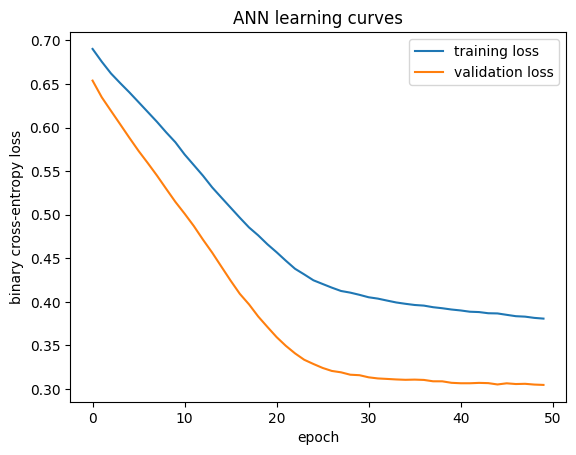

In [67]:
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("ANN learning curves")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy loss")
plt.legend()
plt.savefig("outputs/figures/ann_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

> **Interpretation:** Training ran for all 50 epochs (the maximum, seed 42), and the best epoch was epoch 50, so early stopping never had to trigger (validation loss kept improving). Both curves fall smoothly and stay close together, with no sign of overfitting

### Test the ANN once on the same 60 test records (threshold 0.5)

In [68]:
ann_prob = ann.predict(X_test, verbose=0).ravel()
ann_pred = (ann_prob >= THRESHOLD).astype(int)

In [69]:
ann_accuracy = accuracy_score(y_test, ann_pred)
ann_precision = precision_score(y_test, ann_pred, zero_division=0)
ann_recall = recall_score(y_test, ann_pred, zero_division=0)
ann_f1 = f1_score(y_test, ann_pred, zero_division=0)

### Compare all three models

In [70]:
comparison = pd.DataFrame({
    "accuracy":  [base_accuracy, lr_accuracy, ann_accuracy],
    "precision": [base_precision, lr_precision, ann_precision],
    "recall":    [base_recall, lr_recall, ann_recall],
    "f1":        [base_f1, lr_f1, ann_f1],
}, index=["baseline", "logistic_regression", "ann"])
comparison.to_csv("outputs/metrics_comparison.csv")
comparison.round(3)

,accuracy,precision,recall,f1
baseline,0.583,0.583,1.000,0.737
logistic_regression,0.817,0.833,0.857,0.845
ann,0.850,0.906,0.829,0.866


In [71]:
ann_predictions = pd.DataFrame({
    "record_id": test["record_id"].values,
    "true_label": y_test,
    "predicted_label": ann_pred,
    "probability_class_1": ann_prob.round(6),
})
ann_predictions.to_csv("outputs/ann_test_predictions.csv", index=False)
ann_predictions.to_csv("models/ann_test_predictions.csv", index=False)

In [72]:
ann.save("models/ann_model.keras")

**Interpretation (same 60 test records, threshold 0.5):**

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic regression | 0.817 | 0.833 | 0.857 | 0.845 |
| ANN | 0.833 | 0.838 | 0.886 | 0.861 |

The ANN's F1 is 0.016 higher, which is **one single test record**. On 60 records this is well within chance, so the two models perform **about the same**.
